# ENGR 1451/2451 — Weekly Assignment 2
**10 points**

This assignment applies the descriptive-statistics and visual-exploration methods introduced in the W02A lab notebooks: center and spread, quartiles and outliers, histograms and boxplots, grouped summaries, and the importance of pairing numerical summaries with visualizations.


 **Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.


## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.


## Setup

Put `iris.csv` in a folder named `data` next to this notebook so that the path below works.


In [46]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

iris = pd.read_csv(Path("./data/iris.csv"))
iris.head()


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## LE2-1. Shifting and scaling data (2 pts)

Consider the following measurements:

\[
x = [4,\ 6,\ 8,\ 10,\ 12].
\]

Create two transformed versions:

- **shifted:** \(x + 7\)
- **scaled:** \(3x\)

### A. Predict first (1 pt)

Without calculating, predict what happens to the **mean**, **median**, **sample standard deviation**, and **IQR** after each transformation.

Complete the table in words such as *increases by 7*, *unchanged*, or *multiplied by 3*.

| Statistic | After adding 7 | After multiplying by 3 |
|---|---|---|
| Mean | Increase by 7 | Scale by 3 |
| Median | Increase by 7 | Scale by 3 |
| Sample standard deviation | No change | Scale by 3 |
| IQR | No change | Scale by 3 |


**Answer:**

### B. Verify with Python (1.5 pts)

Create a small summary table for the original, shifted, and scaled data containing:

- mean;
- median;
- sample standard deviation; and
- IQR.

Then state whether the results agree with your predictions.



In [19]:
x = pd.Series([4, 6, 8, 10, 12], name="original")
shifted = x + 7
scaled = 3 * x

# Your code here
mean_initial = x.mean()
mean_shifted = shifted.mean()
mean_scaled = scaled.mean()
median_initial = x.median()
median_shifted = shifted.median()
median_scaled = scaled.median()
std_initial = x.std(ddof=1)
std_shifted = shifted.std(ddof=1)
std_scaled = scaled.std(ddof=1)
iqr_initial = x.quantile(0.75) - x.quantile(0.25)
iqr_shifted = shifted.quantile(0.75) - shifted.quantile(0.25)
iqr_scaled = scaled.quantile(0.75) - scaled.quantile(0.25)

table_display_data = {
    "Intial Values" : [mean_initial,median_initial,std_initial,iqr_initial],
    "Adding 7" : [mean_shifted,median_shifted,std_shifted,iqr_shifted],
    "Multiplying by 3" : [mean_scaled,median_scaled,std_scaled,iqr_scaled]}

table_index = ["Mean","Median","Standard Deviation","IQR"]

table_display = pd.DataFrame(table_display_data,index=table_index)

table_display

,Intial Values,Adding 7,Multiplying by 3
Mean,8.000000,15.000000,24.000000
Median,8.000000,15.000000,24.000000
Standard Deviation,3.162278,3.162278,9.486833
IQR,4.000000,4.000000,12.000000


**Answer:** These results agree with my predictions


## LE2-2. Quartiles, IQR, and outliers (2 pts)

Use the Iris variable `sepal.width`.

1. Calculate \(Q_1\), the median, and \(Q_3\).
2. Calculate the IQR.
3. Calculate the lower and upper Tukey fences:
   \[
   Q_1 - 1.5\,\mathrm{IQR}
   \qquad\text{and}\qquad
   Q_3 + 1.5\,\mathrm{IQR}.
   \]
4. Use Python to identify every Iris observation whose `sepal.width` falls outside these fences.
5. Report how many observations are flagged and state whether they are low outliers, high outliers, or both.


In [49]:
sepal_width = iris["sepal.width"]

# Useful pattern:
# q1 = sepal_width.quantile(0.25)

# Your code here
print("#1")
sepal_width_quartiles = sepal_width.quantile([0.25, 0.5, 0.75])
print("Q1:",sepal_width_quartiles[0.25],
      "| Median:", sepal_width_quartiles[0.5],
      "| Q3:",sepal_width_quartiles[0.75])

print("\n#2")
sepal_width_iqr = sepal_width_quartiles[0.75] - sepal_width_quartiles[0.25]
print("IQR = ",sepal_width_iqr)

print("\n#3")
lower_sw_filter  = sepal_width_quartiles[0.25] - 1.5*sepal_width_iqr
upper_sw_filter= sepal_width_quartiles[0.75] + 1.5*sepal_width_iqr
print("Lower and upper bounds:","<",lower_sw_filter, "|| >",upper_sw_filter)

print("\n#4")
flagged_values = sepal_width[(sepal_width < lower_sw_filter) | (sepal_width > upper_sw_filter)] #checking for values below the low filter OR above the upper filter
print("All outliers: ",flagged_values.tolist())



#1
Q1: 2.8 | Median: 3.0 | Q3: 3.3

#2
IQR =  0.5

#3
Lower and upper bounds: < 2.05 || > 4.05

#4
All outliers:  [4.4, 4.1, 4.2, 2.0]


**Answer:** #5: There are 4 outliers that were flagged in the sepal width data from iris.csv. There are three higher outliers (> 4.05) and one lower outlier (< 2.05)


## LE2-3. Visualizing a distribution and comparing groups (4 pts)

Use `sepal.length` for all parts below.

### A. Histograms and bin choice (1.5 pts)

Create two histograms of the **same** `sepal.length` data:
- one using **6 bins**;
- one using **18 bins**.

Give each plot meaningful axis labels and a title. Then explain briefly:
1. what features of the distribution appear in both histograms; and
2. what changes when the number of bins changes.


AttributeError: 'Figure' object has no attribute 'plot'

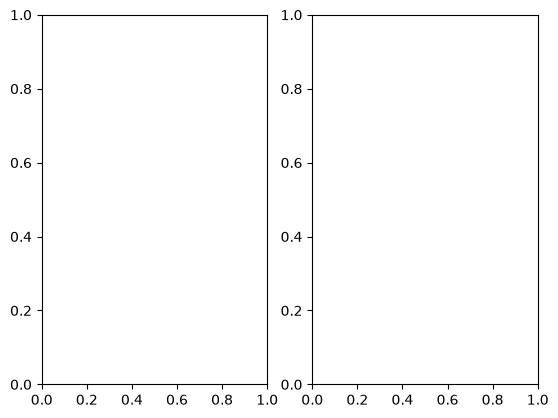

In [58]:
# Your histogram code here
sepal_length = iris["sepal.length"]

axes = plt.subplots(1,2)

axes[0].plot.hist(sepal_length,bins=6)
plt.title("Sepal Length, 6 bins")
plt.ylabel("Counts")


axes[1].plt.hist(sepal_length,bins=18)
plt.title("Sepal Length, 18 bins")
plt.ylabel("Counts")

**Answer:**


### B. Grouped numerical summary (1 pt)

Calculate the `count`, `median`, sample `std`, `min`, and `max` of `sepal.length` for each Iris species using `groupby()` and `agg()`.

Which species has the largest median `sepal.length`? Which has the largest sample standard deviation?


In [5]:
# Useful pattern:
# iris.groupby("variety")["sepal.length"].agg([...])

# Your code here


**Answer:**


### C. Boxplot by species (1.5 pts)

Create a boxplot of `sepal.length` grouped by `variety`.

Give the plot a clear title and axis labels. Then state **two conclusions** supported by the boxplot: one about differences in center and one about differences in spread or overlap among the species.


In [6]:
# Useful pattern:
# iris.boxplot(column="...", by="...")

# Your code here


**Answer:**


## LE2-4. Similar summaries can hide different distributions (2 pts)

The two datasets below have the same mean, median, and sample standard deviation, but their distributions are not the same.

### A. Compare numerical summaries (0.75 pt)

For datasets A and B, calculate the:
- mean;
- median; and
- sample standard deviation.

Confirm that these three numerical summaries are the same (or equal to rounding).


In [7]:
comparison = pd.DataFrame(
    {
        "A": [1, 2, 3, 4, 5, 6, 7, 8, 9],
        "B": [0, 3, 4, 5, 5, 5, 6, 7, 10],
    }
)

comparison

# Useful pattern:
# comparison.agg(["mean", "median", "std"])

# Your code here


,A,B
0,1,0
1,2,3
2,3,4
3,4,5
4,5,5
5,6,5
6,7,6
7,8,7
8,9,10


### B. Visualize the distributions (0.75 pt)

Choose **one** of the following ways to compare datasets A and B:
- histograms using the same bins and x-axis scale; or
- boxplots shown on the same figure.

Give the visualization a clear title and meaningful axis labels.


In [8]:
# Your visualization code here


### C. Interpret (0.5 pt)

What important difference between datasets A and B is visible in your plot but hidden by the mean, median, and sample standard deviation?

In one or two sentences, explain why numerical summaries and visualizations should be used together.

**Answer:**


## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.


<!-- Paste your session record blocks in this cell, one after another. -->

*(session records go here)*
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA2",
  "export_n": 1,
  "session_date": "2026-09-13",
  "messages": [
    {"i": 1, "who": "student", "text": "Can you provide me of how to make a table using a pandas dataframe?"},
    {"i": 2, "who": "tutor", "text": "Explained three ways to build a pandas DataFrame: from a dictionary of lists, from a list of row-dictionaries, and from lists of columns directly, with generic examples and useful attributes (df.columns, df.head(), df.shape). Ended by asking if this was for the assignment or general curiosity."},
    {"i": 3, "who": "student", "text": "How can I adjust the index titles?"},
    {"i": 4, "who": "tutor", "text": "Explained renaming columns (df.rename(columns=...), df.columns = [...]), renaming row index labels (df.rename(index=...), df.set_index()), and naming the index axis itself (df.index.name). Noted rename() returns a new DataFrame by default. Asked if this was for tidying a table being built."},
    {"i": 5, "who": "student", "text": "If I wanted text on both sides of the table, how could I rename the row titles from 0, 1, 2 to a string variable?"},
    {"i": 6, "who": "tutor", "text": "Explained assigning a list directly to df.index (positional replacement, must match row count), including an example building row_names from a loop over some_series.unique(). Also covered df.rename(index={...}) for partial renames and df.set_index('category') for using an existing column. Warned that direct index assignment doesn't validate correspondence to rows. Offered to show df.index.name combined with this."},
    {"i": 7, "who": "student", "text": "Is there a way I can include the row names in the initial dataframe creation?"},
    {"i": 8, "who": "tutor", "text": "Explained passing index= as a constructor argument, with examples from a dictionary of columns and from a list of lists with columns= and index= together, and using a variable for row_names. Noted index= only sets row labels, not the axis name (still needs df.index.name separately). Offered to show combining with column naming at construction time."},
    {"i": 9, "who": "student", "text": "Is it possible to give the data frame a title in the top left?"},
    {"i": 10, "who": "tutor", "text": "Explained df.index.name for the axis label near the top-left corner, df.rename_axis(index=..., columns=...) for naming both axes at once, and df.style.set_caption() for an actual table caption (noting .style returns a Styler, not a DataFrame). Noted pandas has no dedicated top-left corner cell to write arbitrary text into. Asked if this was for polishing an assignment table."},
    {"i": 11, "who": "student", "text": "Thanks"},
    {"i": 12, "who": "tutor", "text": "Acknowledged thanks and invited the student back if they hit snags building the actual assignment tables."},
    {"i": 13, "who": "student", "text": "Is it possible to perform this sort of calculation to identifiy outliers, or must I perform this command twice with the upper and lower bounds? \n\n```python\nflagged_values = sepal_width[sepal_width < lower_sw_filter or sepal_width > upper_sw_filter]\n\n```", "code": true},
    {"i": 14, "who": "tutor", "text": "Explained that Python's `or` doesn't work element-wise on Series/arrays and would raise a ValueError. Showed the fix using bitwise `|` with parentheses around each condition, explained why parentheses are needed (operator precedence), and gave a quick reference for `&`, `|`, `~` versus plain `and`, `or`, `not`. Confirmed one line can handle both bounds."},
    {"i": 15, "who": "student", "text": "Is there a way I can convert the output data to an easily printable data structure?"},
    {"i": 16, "who": "tutor", "text": "Explained several conversion options on generic example: .tolist() for a plain list, .to_string() for a clean multi-line block, .to_numpy() for an array, .describe() for a summary, and reset_index() to turn a Series into a two-column DataFrame. Asked which format matched what the student wanted."},
    {"i": 17, "who": "student", "text": "make my record"}
  ],
  "events": [],
  "parts": [],
  "tutor_assessment": [
    "The student asked no assignment-specific questions this session — all questions were general pandas/Python technique (DataFrame construction, renaming indices, boolean masking with | vs or, converting Series to printable structures), so no assignment step was attempted or blocked on.",
    "No use of the release valve or 'I got it, let's move on' occurred; nothing suggests a tutoring failure this session."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.
